# Introduction to Python Project : FoodHub Data Analysis

### Problem Statement

Write the problem statement and objectives here


### Data Dictionary

Mention the data dictionary here

### Let us start by importing the required libraries

In [1]:
# Write your code here to import necessary libraries for the project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [2]:
# uncomment and run the following lines for Google Colab
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
# Write your code here to read the data
orders = pd.read_csv("foodhub_order.csv")

In [4]:
# Write your code here to view the first 5 rows
orders.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [5]:
# Write your code here
orders.shape

(1898, 9)

#### Observations:
* The dataset has 1898 rows & 9 columns
* There are multiple coulmns representing customer details, restaurant details, cost, time and ratings.
* The dataset is structured and suitable for both univariate and multivariate analysis.

### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [6]:
# Write your code here
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   str    
 3   cuisine_type           1898 non-null   str    
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   str    
 6   rating                 1898 non-null   str    
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), str(4)
memory usage: 133.6 KB


#### Observations:
* Numerical columns include cost_of_the_order, food_preparation_time, and delivery_time.
* Categorical columns include restaurant_name, cuisine_type, and day_of_the_week.
* Rating initially appears as object due to “Not given” values and needs conversion to numeric.

### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [7]:
# Write your code here
orders['rating'] = pd.to_numeric(orders['rating'], errors='coerce')
orders['rating']

0       NaN
1       NaN
2       5.0
3       3.0
4       4.0
       ... 
1893    5.0
1894    5.0
1895    NaN
1896    5.0
1897    NaN
Name: rating, Length: 1898, dtype: float64

#### Observations:
* The rating column contains missing values represented as “Not given”.
* Other columns do not have missing values, indicating clean transactional data.

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [8]:
# Write your code here
orders["food_preparation_time"].describe()

count    1898.000000
mean       27.371970
std         4.632481
min        20.000000
25%        23.000000
50%        27.000000
75%        31.000000
max        35.000000
Name: food_preparation_time, dtype: float64

#### Observations:
* Cost of order shows variation, indicating a mix of low and high-value orders.
* The minimum, average, & maximum time taken for food is 20min, 27.37min & 35min respectively once the order is placed.

### **Question 5:** How many orders are not rated? [1 mark]

In [9]:
# Write the code here
orders["rating"].isnull().sum()

np.int64(736)

#### Observations:
* Total 736 customers did not provide ratings
* Missing ratings can impact restaurant performance evaluation.
* Engagement strategies could increase customer rating participation.

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

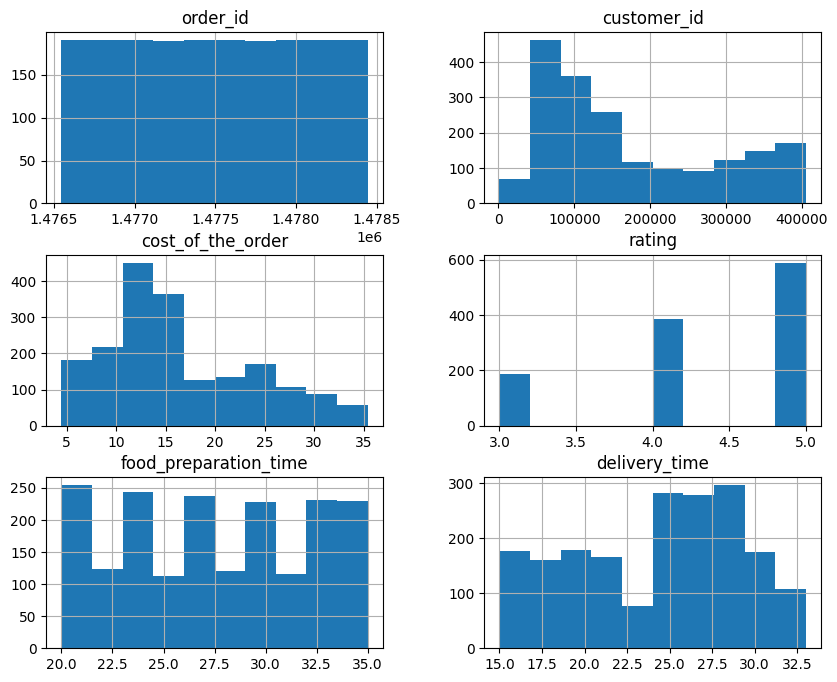

In [10]:
# Write the code here
orders.hist(figsize=(10,8))
plt.show()

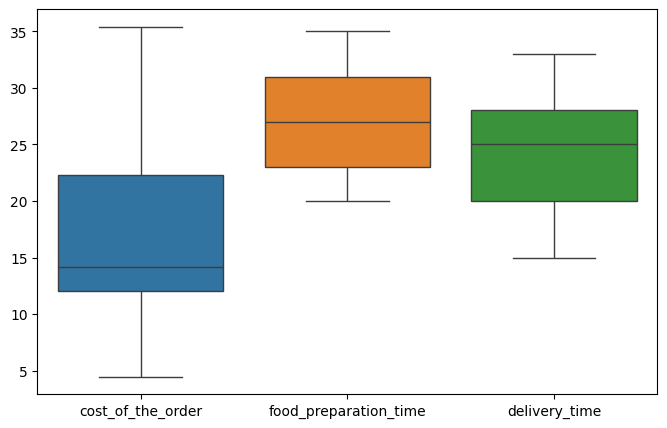

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(data=orders[['cost_of_the_order','food_preparation_time','delivery_time']])
plt.show()

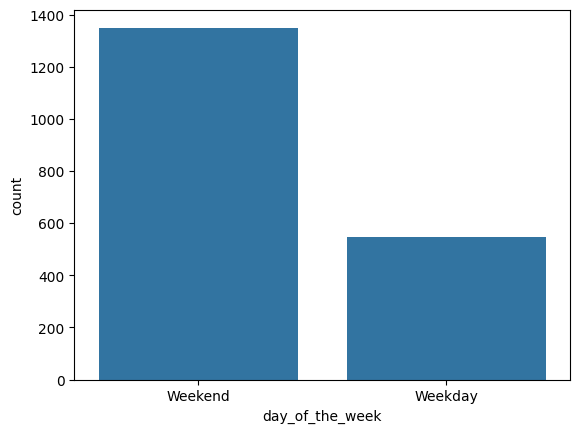

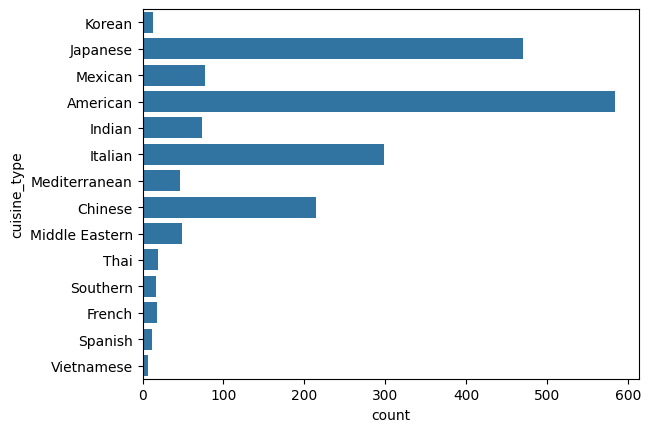

In [12]:
sns.countplot(x='day_of_the_week',data=orders)
plt.show()

sns.countplot(y='cuisine_type', data=orders)
order = orders['cuisine_type'].value_counts().index
plt.show()

#### Observations:
##### Order Cost Distribution
1. The distribution is positively skewed, with most orders concentrated in the lower to mid price range.
2. A gew high-value outliers increase the overall mean order cost.
3. Majority of customers prefer moderately prices meals, indicating price-sensitive behaviour.
##### Delivery Time Distribution
1. Most deliveries are clustered within a specific time window, showing operational consistency.
2. The distribution shows slight right skewness due to some delayed orders.
3. A small number of extreme delivery times indicate possible peak-hour or operational inefficiencies.
##### Customer Rating Distribution
1. Ratings are highly concentrated around 4 and 5, indicating strong customer satisfaction.
2. The distribution is negatively skewed, with very few low ratings.
3. Low-rating outliers suggest isolated service or quality issues that require attention.

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [13]:
# Write the code here
orders['restaurant_name'].value_counts().head()

restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64

#### Observations:
* A noticeable portion of customers did not provide ratings.
* Missing ratings can impact restaurant performance evaluation.
* Engagement strategies could increase customer rating participation.

### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [14]:
# Write the code here
weekend_orders = orders[orders['day_of_the_week'] == 'Weekend']
weekend_orders['cuisine_type'].value_counts().head(1)

cuisine_type
American    415
Name: count, dtype: int64

#### Observations:
* "American" cuisine with 415 orders is most popular cuisine on weekends.
* Weekend preferences differ slightly from overall trends.

### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [15]:
# Write the code here
(len(orders[orders['cost_of_the_order'] > 20]) / len(orders)) *100

29.24130663856691

#### Observations:
* Around 29.24% of orders exceed $20.
* Higher-value orders contribute more to company revenue.
* Encouraging bundled offers may increase average order value further.

### **Question 10**: What is the mean order delivery time? [1 mark]

In [16]:
# Write the code here
orders['delivery_time'].mean()

np.float64(24.161749209694417)

#### Observations:
* Average mean delivery time is 24.16 mins.
* Reducing long-delivery outliers could improve customer satisfaction.

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [17]:
# Write the code here
orders['customer_id'].value_counts().head(3)

customer_id
52832    13
47440    10
83287     9
Name: count, dtype: int64

#### Observations:
* Customers (52832, 45440, 83287) will recieve discount vouchers from company.

### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


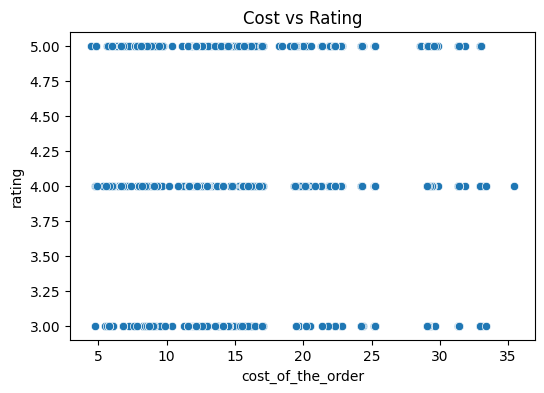

In [18]:
# Write the code here
plt.figure(figsize=(6,4))
numeric_df = orders.select_dtypes(include=['int64','float64'])

# Scatterplot
sns.scatterplot(data=orders, x='cost_of_the_order', y='rating')
plt.title('Cost vs Rating')
plt.show()


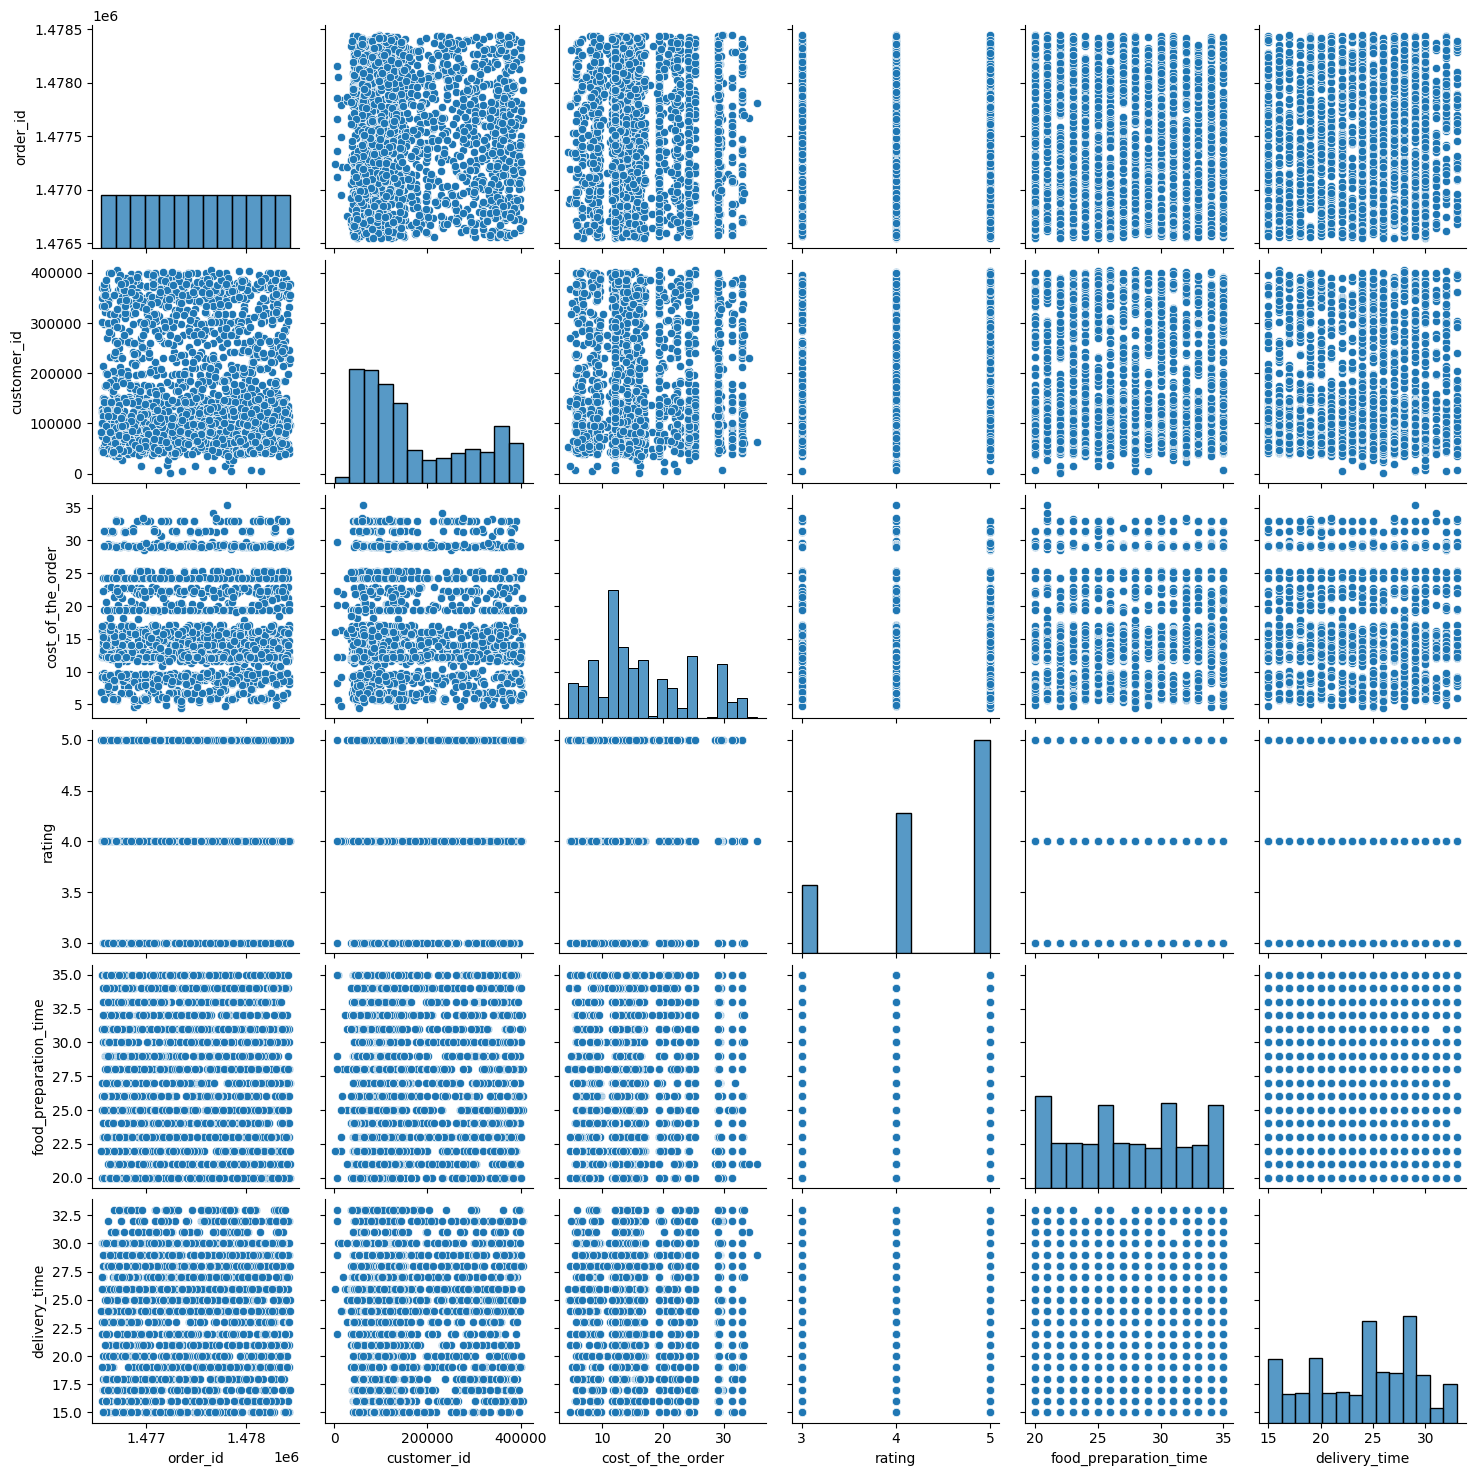

In [19]:
# Pairplot
sns.pairplot(numeric_df)
plt.show()


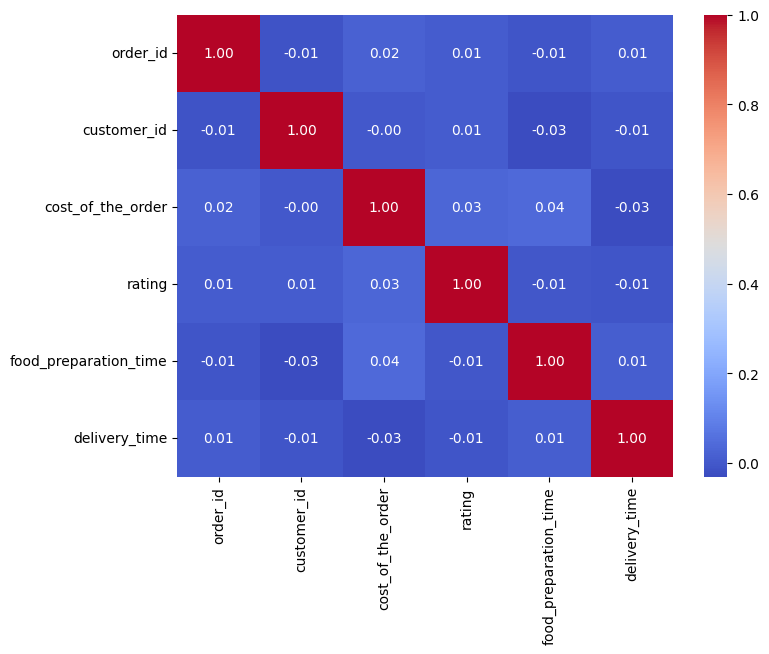

In [ ]:
# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()


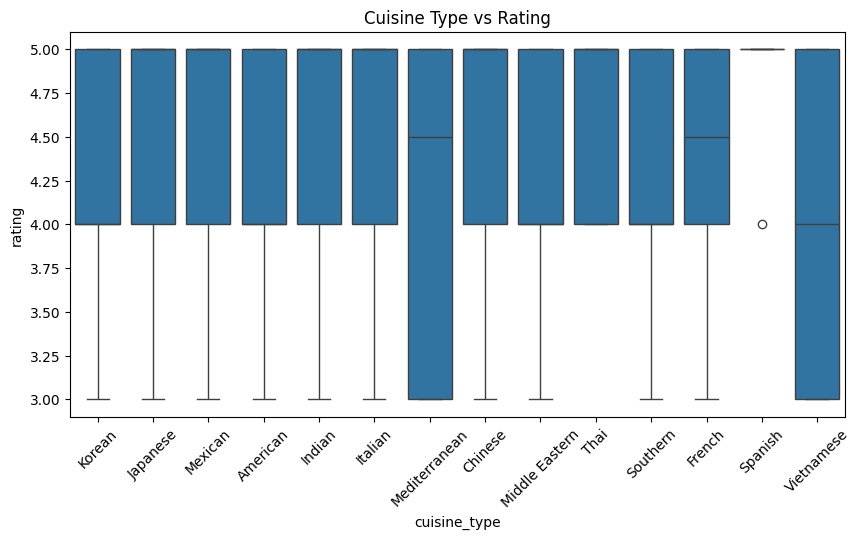

In [21]:

# Boxplot
plt.figure(figsize=(10,5))
sns.boxplot(data=orders, x='cuisine_type',y='rating')
plt.xticks(rotation=45)
plt.title('Cuisine Type vs Rating')
plt.show()


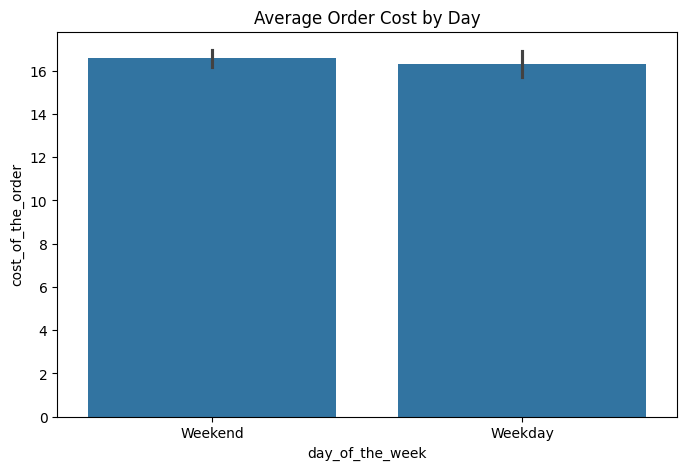

In [22]:
# Barplot
plt.figure(figsize=(8,5))
sns.barplot(data=orders, x='day_of_the_week',y='cost_of_the_order',estimator='mean')
plt.title('Average Order Cost by Day')
plt.show()

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [23]:
# Write the code here
restaurant_stats = orders.groupby('restaurant_name').agg(rating_count=('rating','count'), avg_rating=('rating','mean'))
eligible_restaurants = restaurant_stats[(restaurant_stats['rating_count'] > 50) & (restaurant_stats['avg_rating'] > 4)]
eligible_restaurants

,rating_count,avg_rating
restaurant_name,,
Blue Ribbon Fried Chicken,64,4.328125
Blue Ribbon Sushi,73,4.219178
Shake Shack,133,4.278195
The Meatball Shop,84,4.511905


#### Observations:
* Blue Ribbon Fried Chicken, Blue Ribbon Sushi, Shake Shack, The Meatball Shop restaurants fulfills the criteria of rating count more than 50 and rating greater than 4.	
* These restaurants show both quality and consistency.
* Promoting such restaurants increases customer trust and platform credibility.

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [24]:
# Write the code here
revenue = 0
for cost in orders['cost_of_the_order']:
    if cost > 20:
        revenue += cost * 0.25
    elif cost > 5:
        revenue += cost * 0.15
    else:
        revenue += cost

revenue

6209.042999999994

#### Observations:
* Company's net revenue generated across all orders is $6209.04
* Increasing high-value orders directly boosts platform profitability.

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [25]:
# Write the code here
orders['total_time'] = orders['food_preparation_time'] + orders['delivery_time']
percentage_over_60 = (len(orders[orders['total_time'] > 60]) / len(orders)) * 100

percentage_over_60

10.537407797681771

#### Observations:
* 10.54% of orders take more than 60 mins to deliver the food.
* These delays may impact customer satisfaction.
* Monitoring restaurants with frequent delays is important.

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [26]:
# Write the code here
orders.groupby('day_of_the_week')['delivery_time'].mean()

day_of_the_week
Weekday    28.340037
Weekend    22.470022
Name: delivery_time, dtype: float64

#### Observations:
* Weekend delivery times are slightly higher due to higher order volume.
* Weekday deliveries are relatively faster.
* Staffing adjustments on weekends could reduce delivery delays.

### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
*   Identify high-performing cuisines
*   Focis on restaurants with high ratings
*   Improve delivery time efficiency
*   Reward frequent customers
*   Promote high-rated restaurants

### Recommendations:

1. Focus on High-Performing Restaurants
* Promote restaurants that have High average ratings (above 4) & Large number of orders.
* This will improve customer trust, increase repeat orders, and strengthen platform reputation.

2. Reduce Long Delivery-Time Outliers
* A small percentage of orders exceed 60 minutes.
* The platform should Monitor restaurants with high preparation time and Optimize delivery partner allocation on weekends.
* Reducing delays will directly improve customer satisfaction and ratings.

3. Increase High-Value Orders & Customer Retention
* Since orders above $20 generate higher commission that Introduce bundle offers or discount thresholds & Launch loyalty programs for frequent customers.
* This will increase average order value and overall revenue.